First 5 Rows
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   4.791028  -0.514649  -6.296562  -5.449043   0.431670   0.006702   
1   0.637022   5.945563  -2.687462  -5.642297   1.007341   0.131381   
2  -0.066081  -3.677943  -1.207308  -2.016189  -2.348021  -3.080265   
3   2.552505   2.674526  -1.977820  -1.262897  -2.477825  -0.059247   
4  -4.846352  -1.012489  -3.542112  -2.766310   0.300696   1.420399   

   feature_7  feature_8  feature_9  feature_10  feature_11  feature_12  \
0   4.236906  -6.875053  -0.531434   -1.550330    2.850726    1.117535   
1   3.039483 -10.960291  -6.802535    0.023594    3.980999   -0.240207   
2   1.379003  -2.209901   2.084319    0.975721   -3.662404    0.844252   
3   4.512908  -4.470499  -2.796034    0.119433   -1.680597   -0.851670   
4   2.478424  -8.975629  -3.231219    0.448776   -0.822367   -1.107727   

   feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  \
0   -2.466881    1.241253    3.460250 

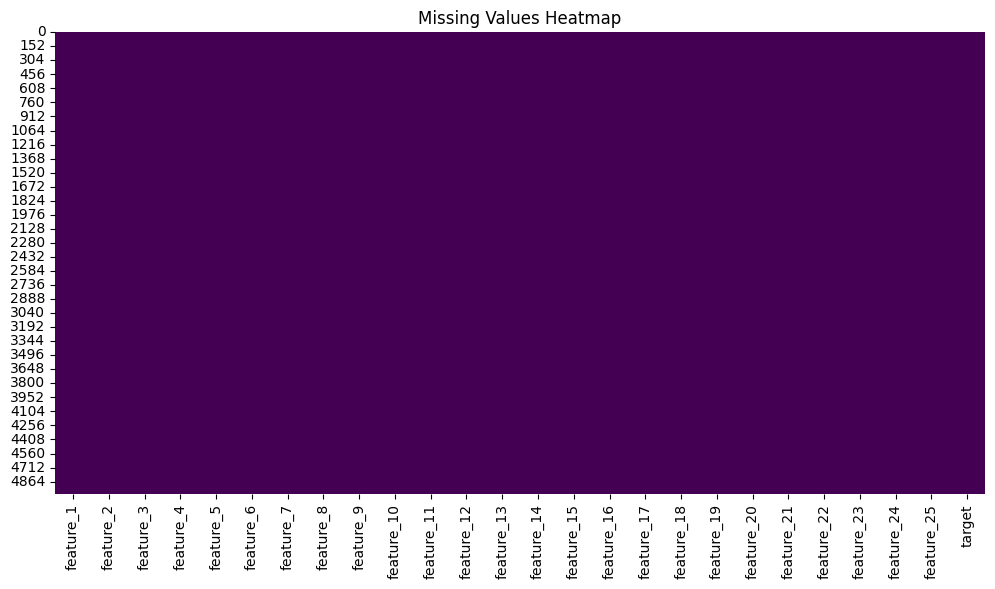


Duplicate Rows: 0


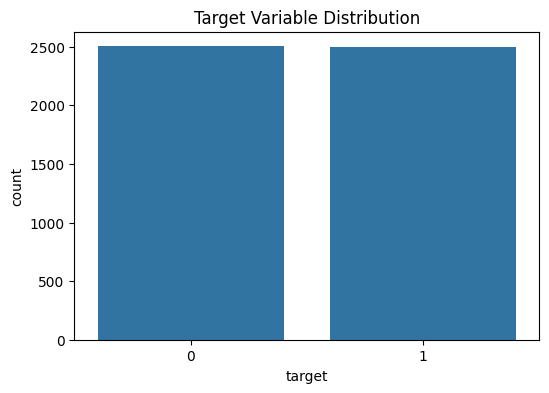

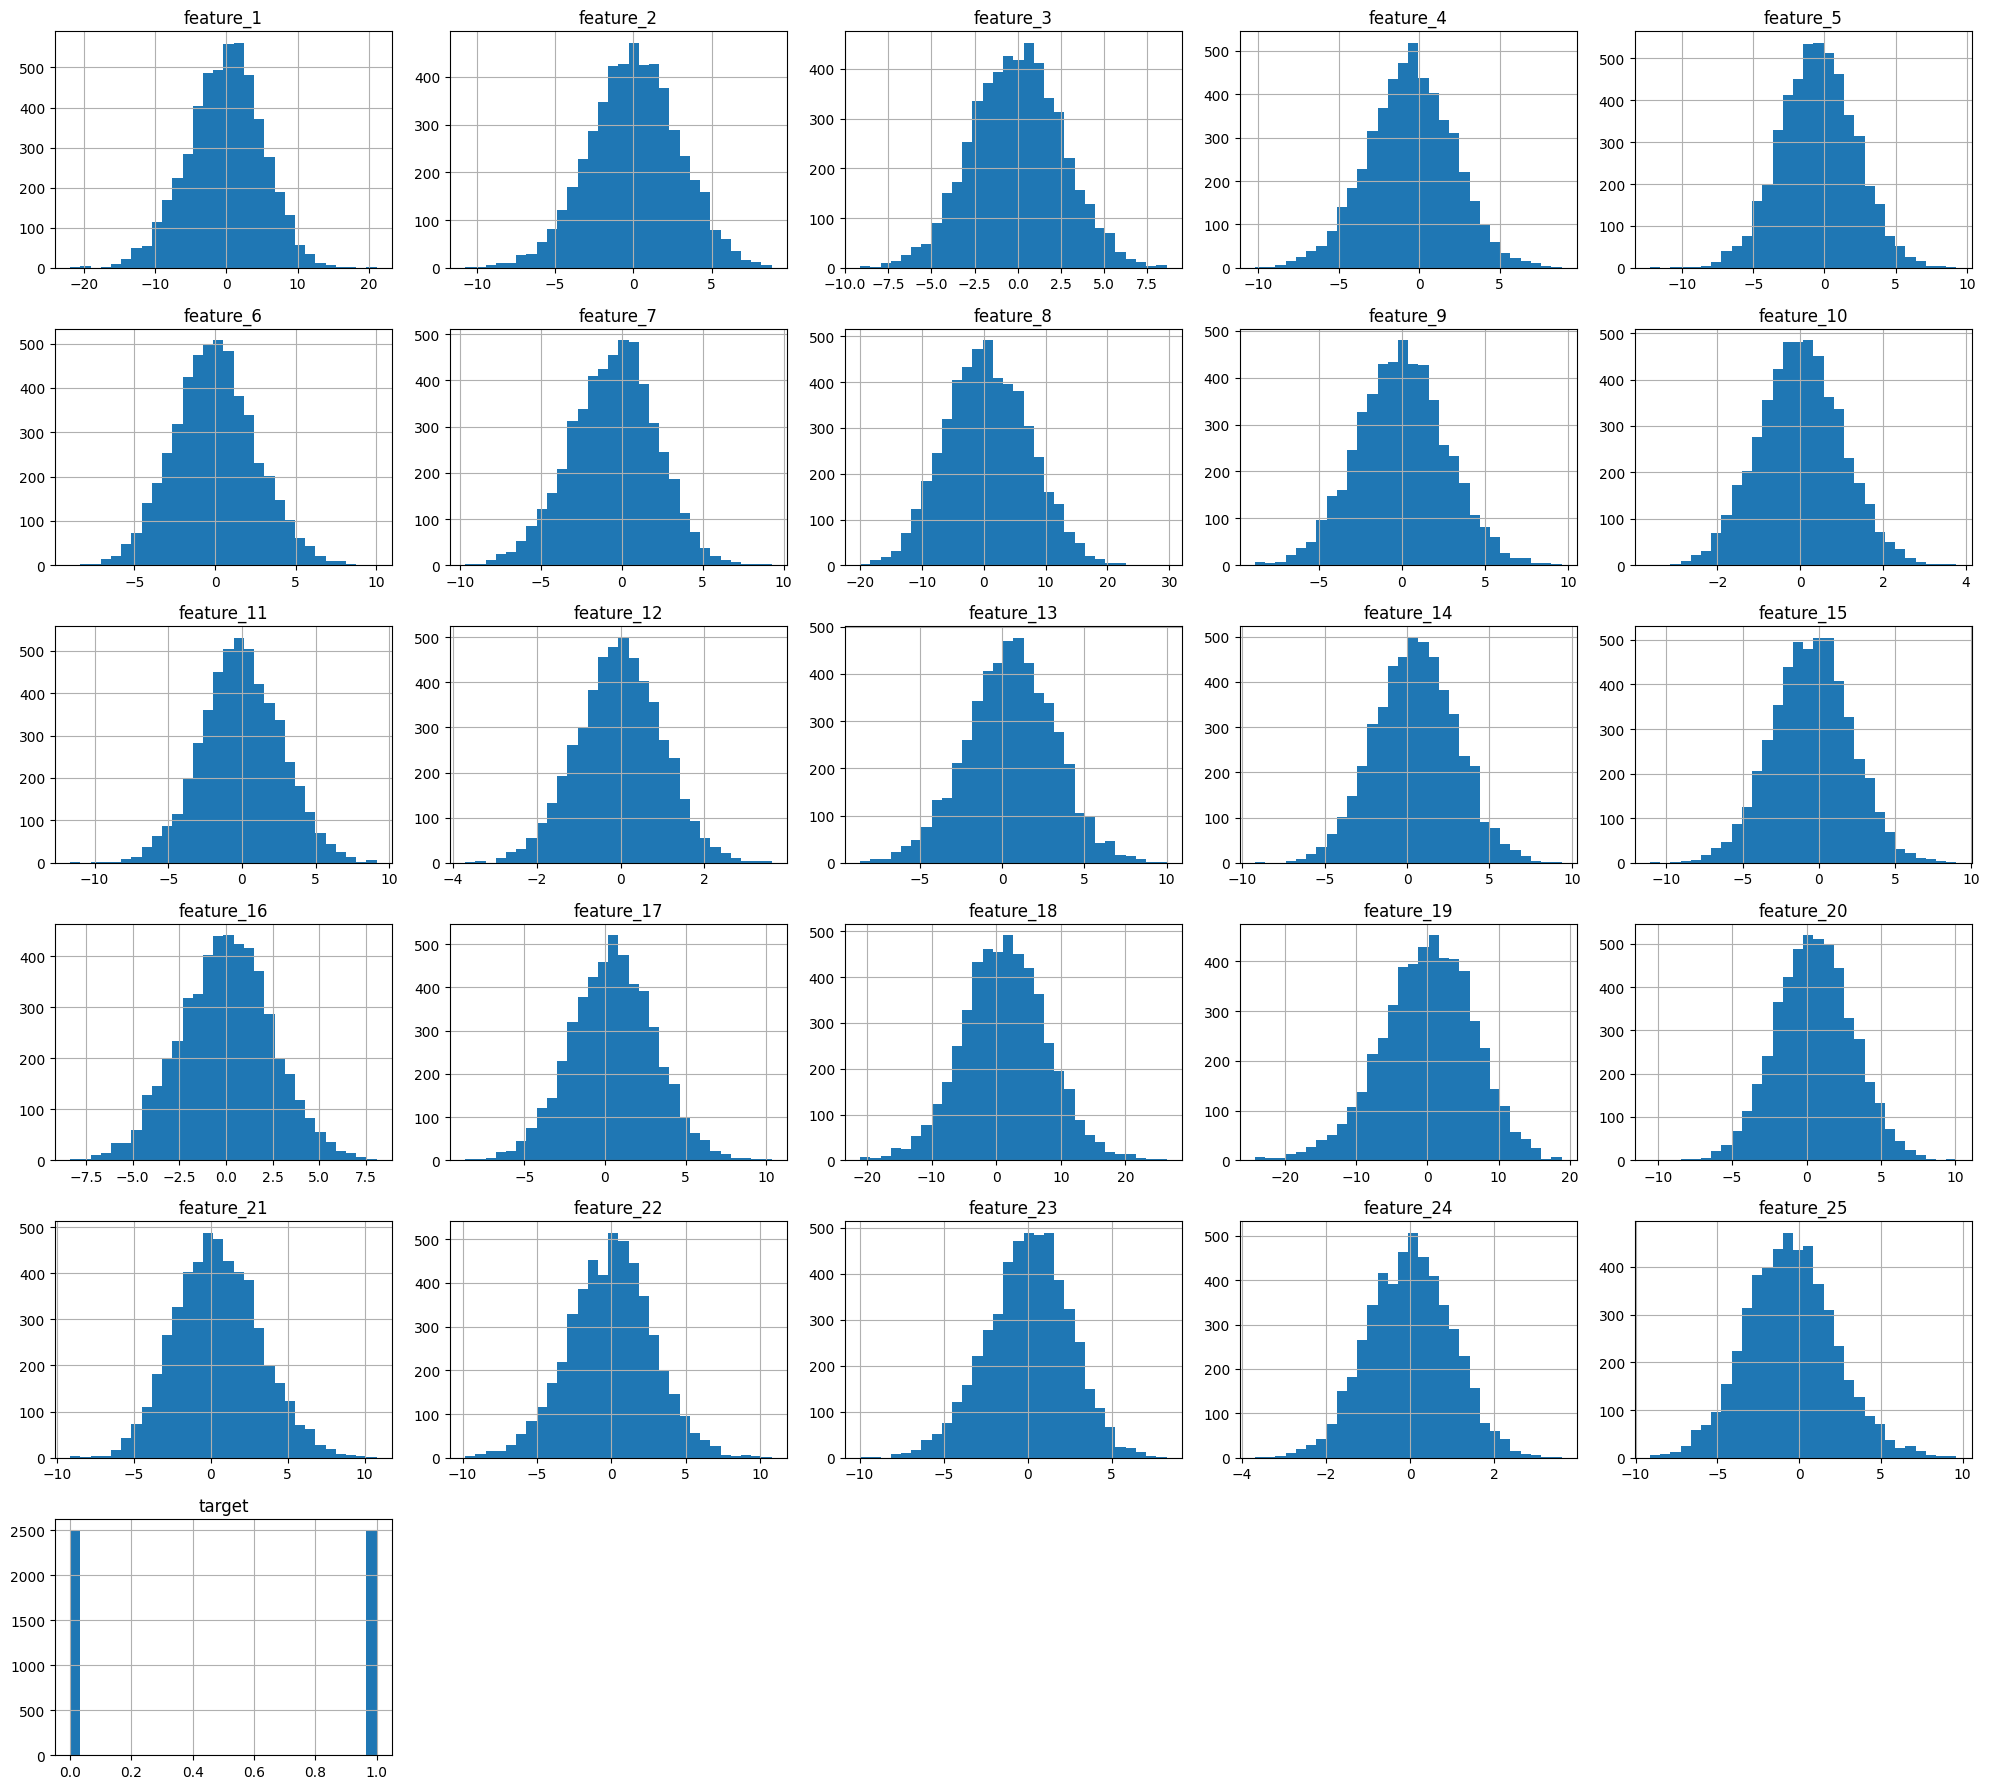

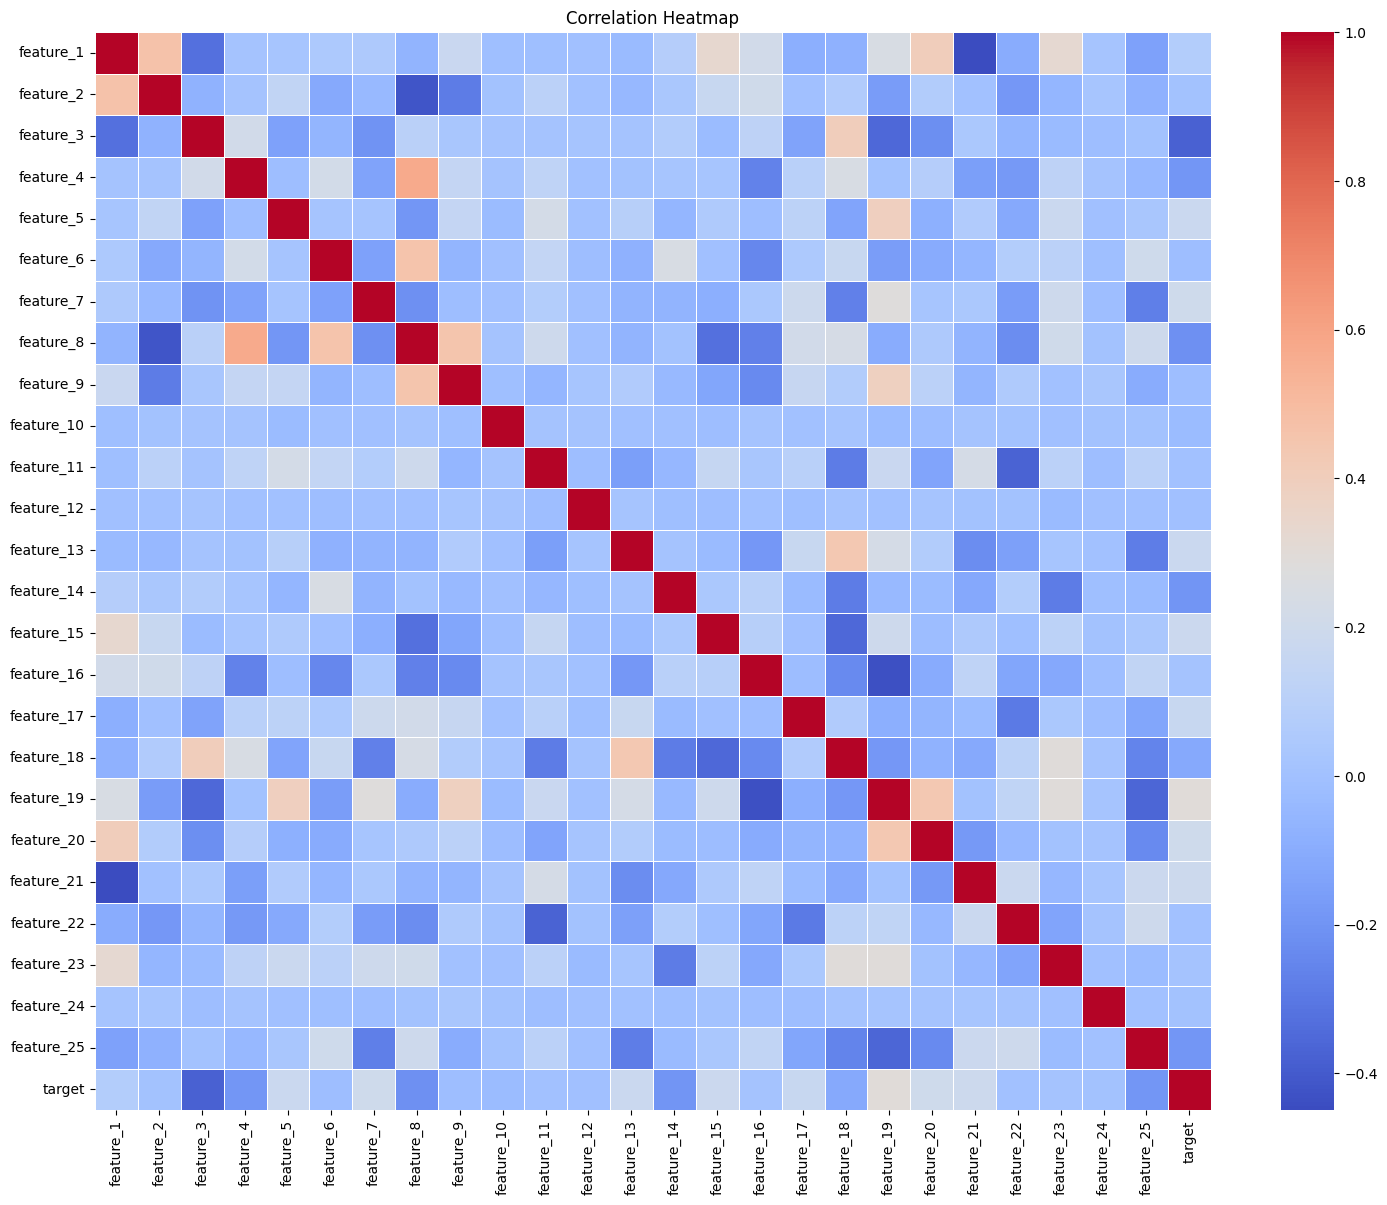


Top Correlated Features with Target
target        1.000000
feature_19    0.297124
feature_20    0.201125
feature_7     0.200201
feature_21    0.185865
feature_15    0.179246
feature_13    0.177546
feature_5     0.176383
feature_17    0.163767
feature_1     0.071776
feature_23    0.012049
feature_16    0.010544
feature_24    0.007853
feature_2     0.005851
feature_22    0.001619
feature_11   -0.001967
feature_12   -0.003846
feature_6    -0.016754
feature_9    -0.018613
feature_10   -0.027018
feature_18   -0.113044
feature_25   -0.192577
feature_4    -0.194381
feature_14   -0.198452
feature_8    -0.216142
feature_3    -0.378622
Name: target, dtype: float64


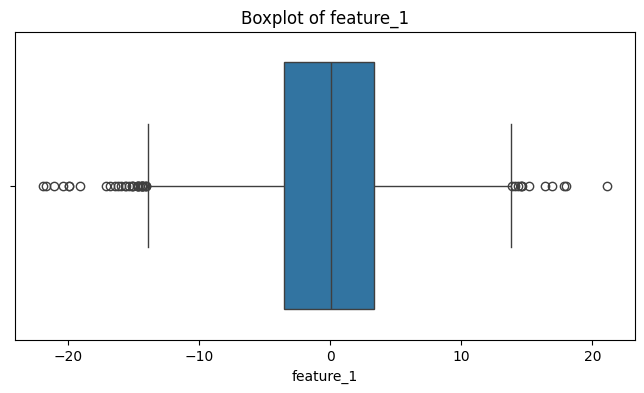

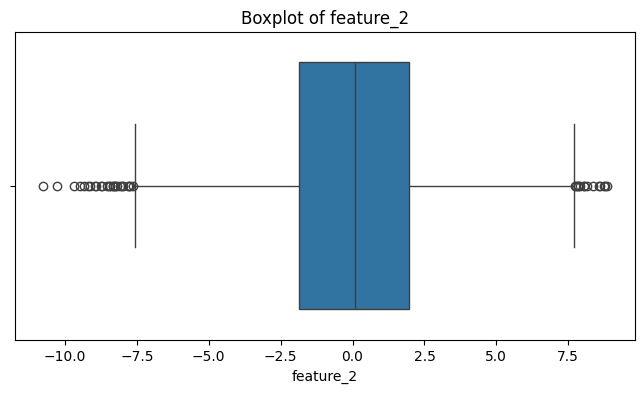

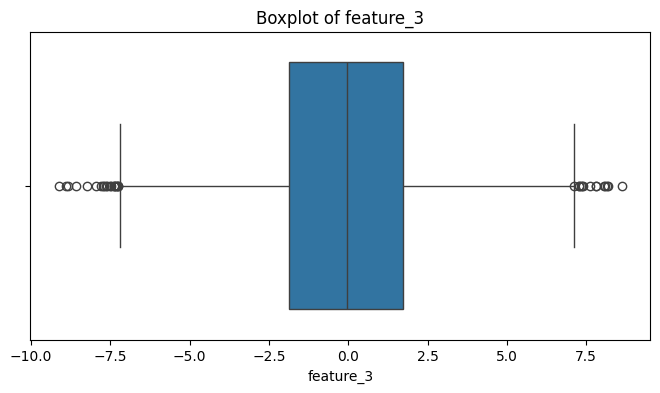

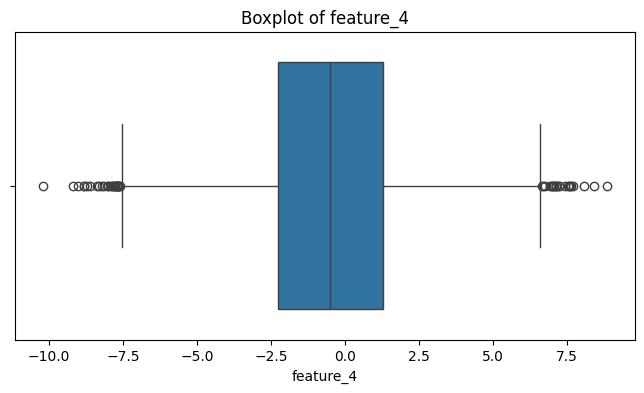

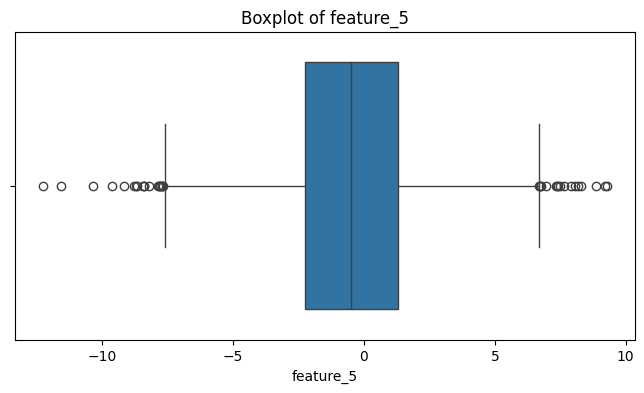

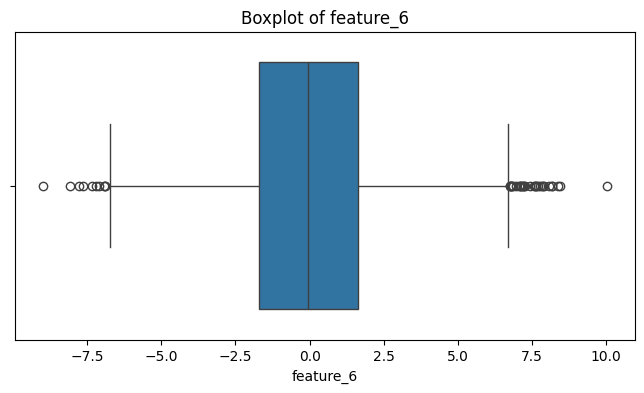

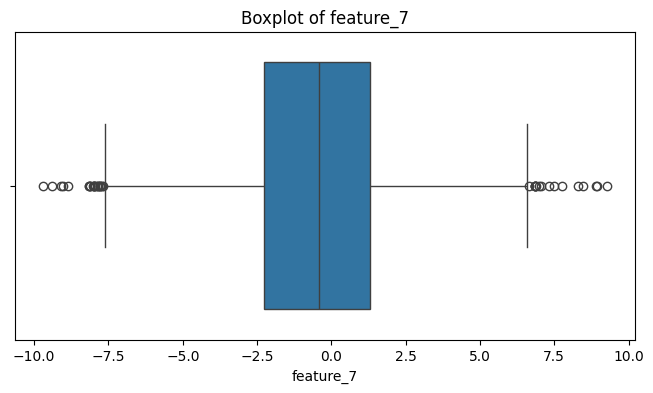

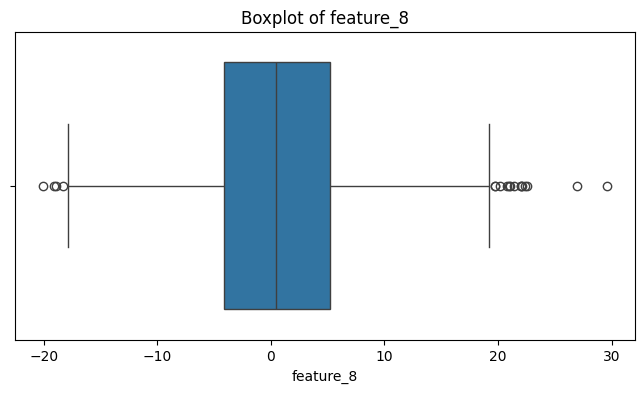

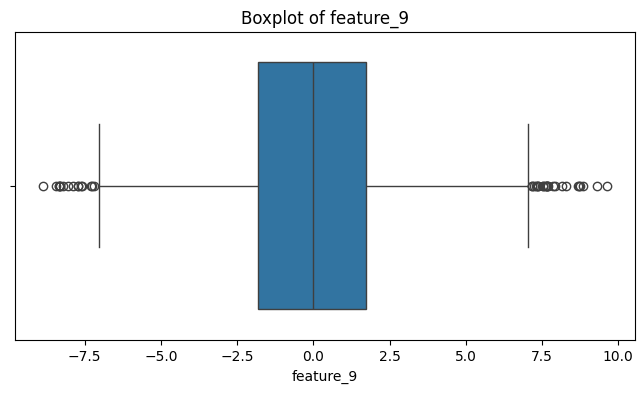

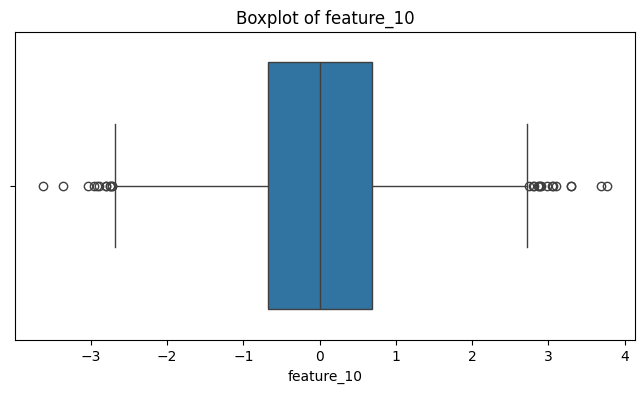

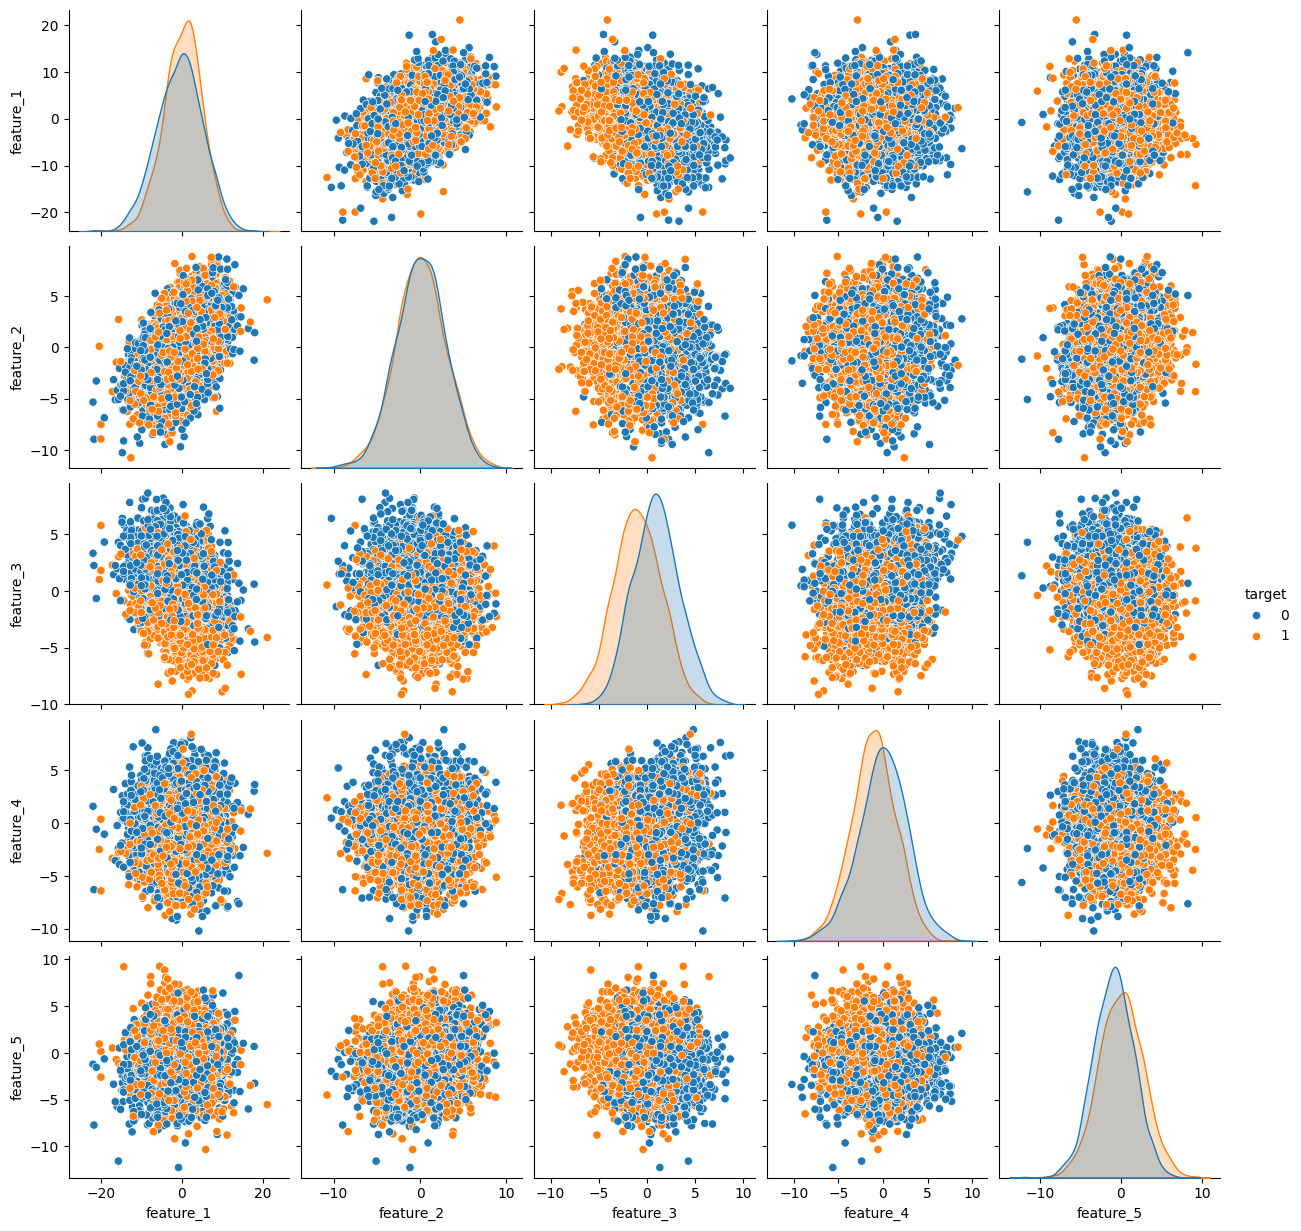


Class Distribution
target
0    2503
1    2497
Name: count, dtype: int64

Class Percentage
target
0    50.06
1    49.94
Name: proportion, dtype: float64

Feature Means
feature_1    -0.164949
feature_2     0.067700
feature_3    -0.043466
feature_4    -0.536835
feature_5    -0.465912
feature_6    -0.005980
feature_7    -0.511592
feature_8     0.608822
feature_9    -0.010926
feature_10    0.005682
feature_11   -0.024159
feature_12   -0.017236
feature_13    0.515061
feature_14    0.517093
feature_15   -0.471169
feature_16    0.015350
feature_17    0.502617
feature_18    1.319489
feature_19    0.029138
feature_20    0.516698
feature_21    0.478338
feature_22   -0.027693
feature_23    0.034133
feature_24   -0.011111
feature_25   -0.517641
target        0.499400
dtype: float64

Feature Standard Deviations
feature_1     5.233621
feature_2     2.870415
feature_3     2.632281
feature_4     2.669497
feature_5     2.663734
feature_6     2.551036
feature_7     2.649273
feature_8     6.741905
featur

In [3]:
# ================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv('../data/raw/data.csv')

# ================================
# BASIC INFORMATION
# ================================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ================================
# MISSING VALUES
# ================================

print("\nMissing Values")
print(df.isnull().sum())

# Visualize Missing Values
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ================================
# DUPLICATE VALUES
# ================================

print("\nDuplicate Rows:", df.duplicated().sum())

# ================================
# TARGET VARIABLE DISTRIBUTION
# ================================

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Target Variable Distribution")
plt.show()

# ================================
# FEATURE DISTRIBUTIONS
# ================================

df.hist(figsize=(20,18), bins=30)
plt.tight_layout()
plt.show()

# ================================
# CORRELATION MATRIX
# ================================

plt.figure(figsize=(18,14))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# ================================
# TOP CORRELATED FEATURES
# ================================

target_corr = correlation['target'].sort_values(ascending=False)

print("\nTop Correlated Features with Target")
print(target_corr)

# ================================
# BOXPLOTS FOR OUTLIERS
# ================================

for column in df.columns[:10]:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot of {column}")
    
    plt.show()

# ================================
# PAIRPLOT (LIMITED FEATURES)
# ================================

sample_features = df.columns[:5]

sns.pairplot(
    df[sample_features.tolist() + ['target']],
    hue='target'
)

plt.show()

# ================================
# CLASS BALANCE CHECK
# ================================

print("\nClass Distribution")
print(df['target'].value_counts())

print("\nClass Percentage")
print(df['target'].value_counts(normalize=True) * 100)

# ================================
# FEATURE SCALING CHECK
# ================================

print("\nFeature Means")
print(df.mean())

print("\nFeature Standard Deviations")
print(df.std())

# ================================
# SAVE CLEANED DATASET
# ================================

df.to_csv('../data/processed/cleaned_data.csv', index=False)

print("\nCleaned dataset saved successfully!")

# ================================
# EDA COMPLETED
# ================================

print("\nEDA Completed Successfully!")